# Nepali News Classifier - Training Statistics

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

## 1. Dataset Distribution

In [2]:
DATA_DIR = Path("data")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

with open(DATA_DIR / "labels.json") as f:
    label2id = json.load(f)
id2label = {v: k for k, v in label2id.items()}

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Categories: {list(label2id.keys())}")

Train: 28800 | Val: 3600 | Test: 3600
Categories: ['economy', 'global', 'health', 'national', 'politics', 'sports']


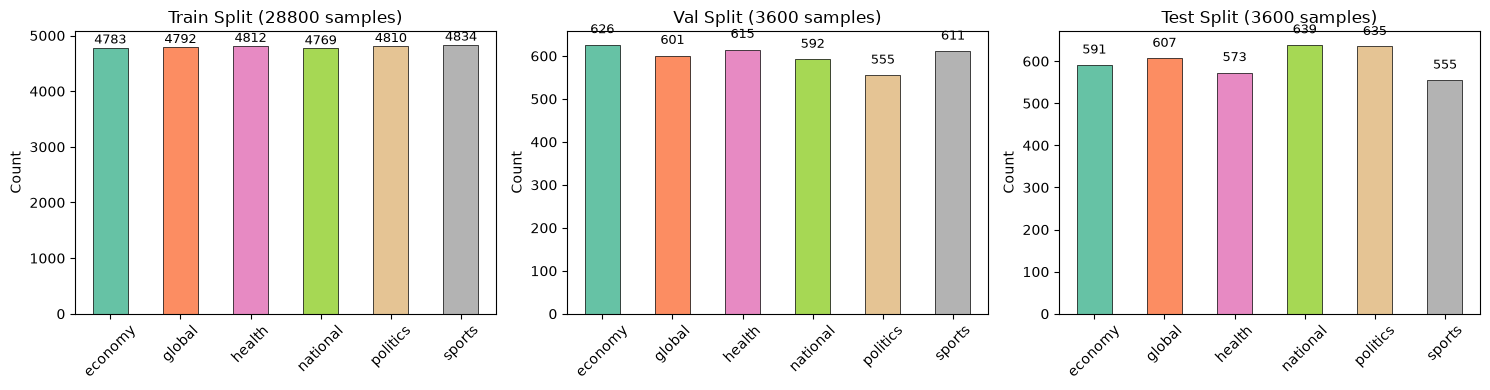

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [("Train", train_df), ("Val", val_df), ("Test", test_df)]):
    counts = df["category"].value_counts().sort_index()
    colors = plt.cm.Set2(np.linspace(0, 1, len(counts)))
    counts.plot.bar(ax=ax, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(f"{name} Split ({len(df)} samples)")
    ax.set_ylabel("Count")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 2. Training Loss Curve

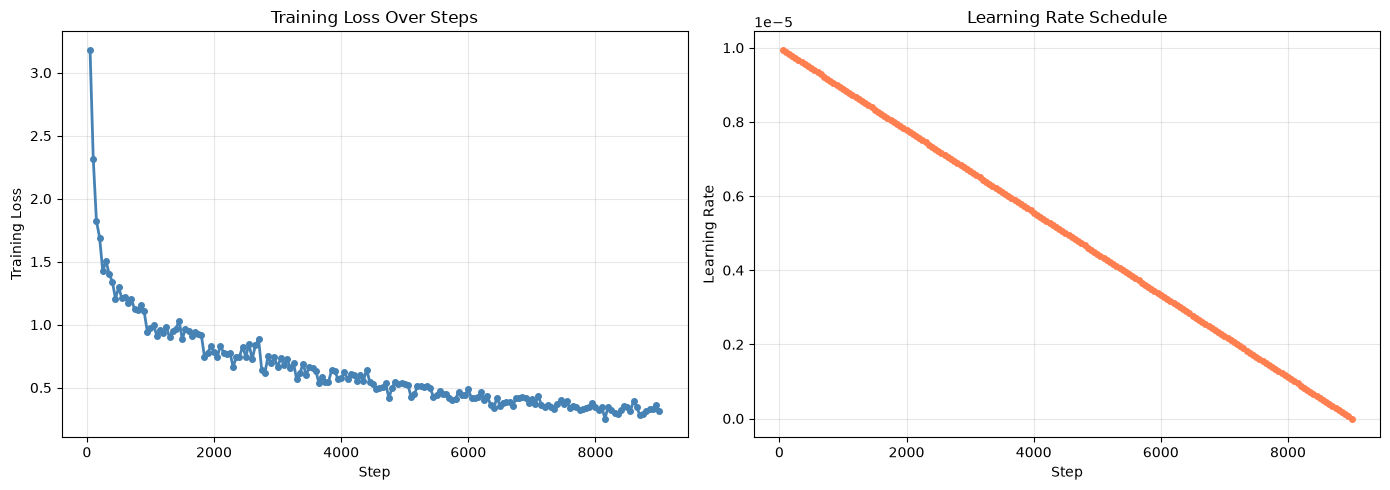


Epoch 1 eval accuracy: 0.8086
Epoch 1 eval loss: 0.5316


In [4]:
MODEL_DIR = Path("model")

log_file = None
for ckpt in sorted(MODEL_DIR.glob("checkpoints/checkpoint-*")):
    state_file = ckpt / "trainer_state.json"
    if state_file.exists():
        log_file = state_file

if log_file:
    with open(log_file) as f:
        state = json.load(f)
    logs = state["log_history"]

    train_logs = [l for l in logs if "loss" in l]
    eval_logs = [l for l in logs if "eval_loss" in l]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    steps = [l["step"] for l in train_logs]
    losses = [l["loss"] for l in train_logs]
    lrs = [l["learning_rate"] for l in train_logs]

    ax1.plot(steps, losses, "o-", color="steelblue", linewidth=2, markersize=4)
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Training Loss")
    ax1.set_title("Training Loss Over Steps")
    ax1.grid(True, alpha=0.3)

    ax2.plot(steps, lrs, "o-", color="coral", linewidth=2, markersize=4)
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("Learning Rate Schedule")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if eval_logs:
        print(f"\nEpoch 1 eval accuracy: {eval_logs[0]['eval_accuracy']:.4f}")
        print(f"Epoch 1 eval loss: {eval_logs[0]['eval_loss']:.4f}")
else:
    print("No checkpoint logs found.")

## 3. Run Model Evaluation on Test Set

In [5]:
MODEL_NAME = "Rajan/NepaliBERT"
MAX_LEN = 128

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR))
model.eval()
model.to(device)

print(f"Model loaded. Classes: {list(model.config.id2label.values())}")

Device: cuda


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Model loaded. Classes: ['economy', 'global', 'health', 'national', 'politics', 'sports']


In [6]:
texts = test_df["text"].tolist()
true_labels = test_df["label"].tolist()

BATCH = 32
pred_labels = []
all_probs = []

with torch.no_grad():
    for i in range(0, len(texts), BATCH):
        batch_texts = texts[i : i + BATCH]
        enc = tokenizer(batch_texts, max_length=MAX_LEN, padding=True, truncation=True, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)
        pred_labels.extend(probs.argmax(dim=-1).cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

print(f"Evaluated {len(texts)} samples.")

Evaluated 3600 samples.


## 4. Confusion Matrix

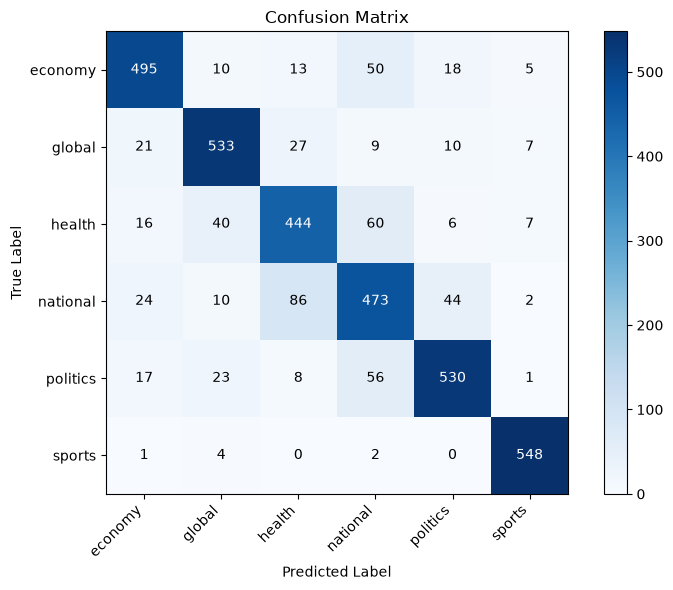

In [7]:
label_names = [id2label[i] for i in range(len(id2label))]
cm = confusion_matrix(true_labels, pred_labels)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(label_names)),
    yticks=np.arange(len(label_names)),
    xticklabels=label_names,
    yticklabels=label_names,
    ylabel="True Label",
    xlabel="Predicted Label",
    title="Confusion Matrix",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

## 5. Per-Class Metrics

In [8]:
report = classification_report(true_labels, pred_labels, target_names=label_names, output_dict=True)

metrics_df = pd.DataFrame({
    "precision": [report[c]["precision"] for c in label_names],
    "recall": [report[c]["recall"] for c in label_names],
    "f1-score": [report[c]["f1-score"] for c in label_names],
    "support": [int(report[c]["support"]) for c in label_names],
}, index=label_names)

print(metrics_df.to_string())
print(f"\nAccuracy: {report['accuracy']:.4f}")

          precision    recall  f1-score  support
economy    0.862369  0.837563  0.849785      591
global     0.859677  0.878089  0.868786      607
health     0.768166  0.774869  0.771503      573
national   0.727692  0.740219  0.733902      639
politics   0.871711  0.834646  0.852776      635
sports     0.961404  0.987387  0.974222      555

Accuracy: 0.8397


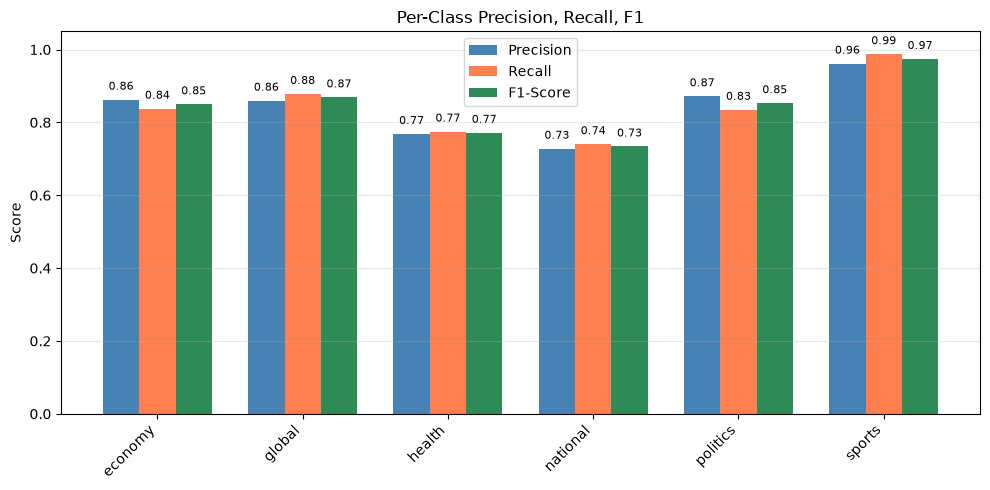

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(label_names))
width = 0.25

ax.bar(x - width, metrics_df["precision"], width, label="Precision", color="steelblue")
ax.bar(x, metrics_df["recall"], width, label="Recall", color="coral")
ax.bar(x + width, metrics_df["f1-score"], width, label="F1-Score", color="seagreen")

ax.set_ylabel("Score")
ax.set_title("Per-Class Precision, Recall, F1")
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for i, (p, r, f) in enumerate(zip(metrics_df["precision"], metrics_df["recall"], metrics_df["f1-score"])):
    ax.text(i - width, p + 0.02, f"{p:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(i, r + 0.02, f"{r:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width, f + 0.02, f"{f:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Confidence Distribution

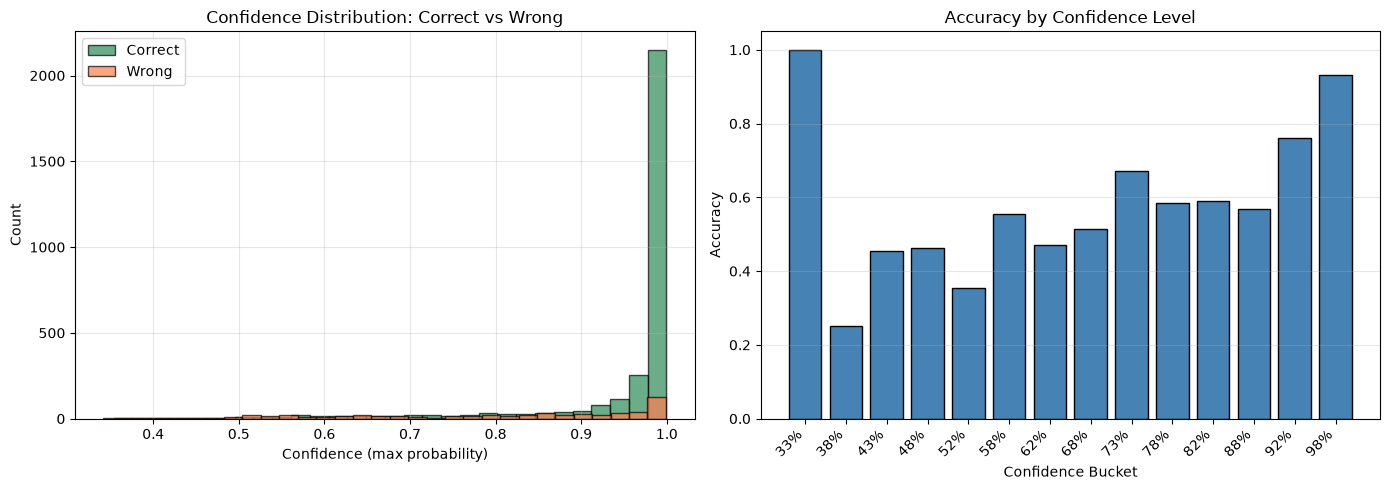

In [10]:
all_probs = np.array(all_probs)
max_probs = all_probs.max(axis=1)
correct = np.array(pred_labels) == np.array(true_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(max_probs[correct], bins=30, alpha=0.7, label="Correct", color="seagreen", edgecolor="black")
ax1.hist(max_probs[~correct], bins=30, alpha=0.7, label="Wrong", color="coral", edgecolor="black")
ax1.set_xlabel("Confidence (max probability)")
ax1.set_ylabel("Count")
ax1.set_title("Confidence Distribution: Correct vs Wrong")
ax1.legend()
ax1.grid(True, alpha=0.3)

bins = np.arange(0, 1.05, 0.05)
acc_per_bin = []
counts_per_bin = []
bin_centers = []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (max_probs >= lo) & (max_probs < hi)
    if mask.sum() > 0:
        acc_per_bin.append(correct[mask].mean())
        counts_per_bin.append(mask.sum())
        bin_centers.append((lo + hi) / 2)

ax2.bar([f"{c:.0%}" for c in bin_centers], acc_per_bin, color="steelblue", edgecolor="black")
ax2.set_xlabel("Confidence Bucket")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy by Confidence Level")
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3, axis="y")
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 7. Text Length Distribution

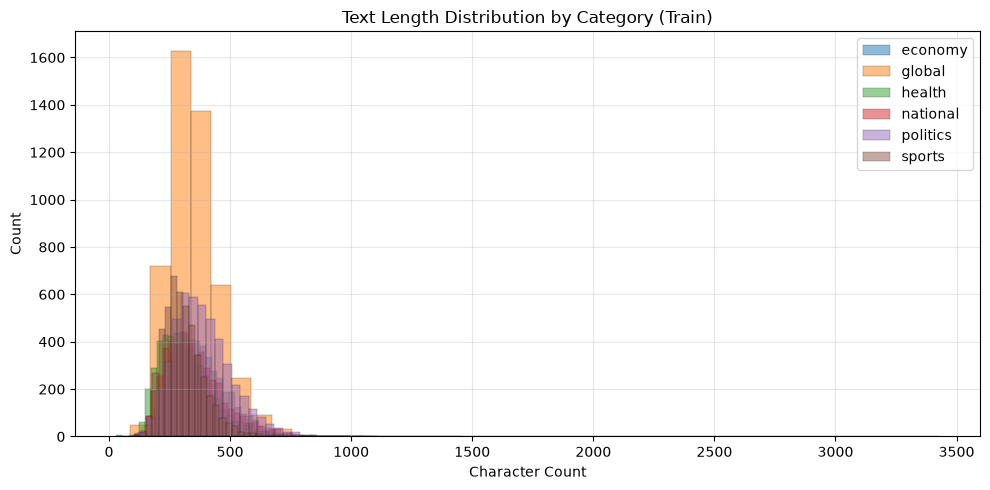

In [11]:
train_df["text_len"] = train_df["text"].str.len()

fig, ax = plt.subplots(figsize=(10, 5))
for cat in sorted(train_df["category"].unique()):
    subset = train_df[train_df["category"] == cat]["text_len"]
    ax.hist(subset, bins=40, alpha=0.5, label=cat, edgecolor="black", linewidth=0.3)

ax.set_xlabel("Character Count")
ax.set_ylabel("Count")
ax.set_title("Text Length Distribution by Category (Train)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()